In [434]:
import numpy as np
import matplotlib.pylab as plt
import pandas as pd
import juliet

In [435]:
def get_K(P,Mp, Ms):
    '''
    P should be in days
    Mp should be in mass of jupiter
    Ms should be in terms of solar masses

    K is given back in m/s
    '''
    K = 28.4 * ((P/365.2422)**(-1/3)) * (Mp) * ((Ms)**(-2/3))

    return K

def get_RV(P, Mp, Ms, N=20, t0=2460988.218692):
    '''
    Assuming no eccentricity and transiting planet (i=90°, e=0)
    P : period [days]
    Mp : planet mass [M_jup]
    Ms : stellar mass [M_sun]
    
    Returns:
        dates : array of observation times [days]
        RV : radial velocity values [m/s]
        K : semi-amplitude [m/s]
    '''
    # --- Custom phase sampling ---
    # Cluster near cosine maxima (0.25) and minima (0.75)
    n_dense = N // 4  # number of dense points per cluster
    n_sparse = N - 2 * n_dense- 2 

    # Uniform sparse coverage across full orbit
    sparse_phases = np.linspace(0, 1, n_sparse, endpoint=False)

    # Denser sampling around peaks/troughs
    peak_phases = np.linspace(0.20, 0.30, n_dense)
    trough_phases = np.linspace(0.70, 0.80, n_dense)
    fixed_phases = np.array([0.25,0.75])
    # Combine and wrap to [0, 1)
    phases = np.sort(np.mod(np.concatenate([sparse_phases, peak_phases, trough_phases,fixed_phases]), 1.0))

    # Convert to times
    dates = t0 + phases * P

    # dates = np.linspace(t0,t0+P,N)
    # Compute true RV curve
    vt = 2 * np.pi * (dates - t0) / P
    K = get_K(P, Mp, Ms)
    RV = K * np.cos(vt + np.pi / 2)  # circular orbit

    return dates, RV, K

def get_uncertainty(final_results,i=0,snr=25,nspec=10):
    template_unc = np.mean(final_results[(i,snr,nspec)]['template_unc'])/np.sqrt(50)
    mala_unc = np.mean(final_results[(i,snr,nspec)]['mala_unc'])/np.sqrt(50)
    intrinsic_unc = np.mean(final_results[(i,snr,nspec)]['intrinsic_unc'])/np.sqrt(50)

    return template_unc, mala_unc, intrinsic_unc

def get_augmented_RVs(RVs, final_results, N=20, i=0, snr=25, nspec=10):
    template_unc, mala_unc, int_unc = get_uncertainty(final_results, i, snr, nspec)
    mala_RVs = RVs + (np.random.permutation(np.array(final_results[(i,snr,nspec)]['mala_z'])*mala_unc.flatten())).reshape(-1, N)
    template_RVs = RVs + (np.random.permutation(np.array(final_results[(i,snr,nspec)]['template_z'])*template_unc.flatten())).reshape(-1, N)
    int_RVs = RVs + (np.random.permutation(np.array(final_results[(i,snr,nspec)]['intrinsic_z'])*int_unc.flatten())).reshape(-1, N)

    mala = np.stack([mala_RVs, np.full_like(mala_RVs, mala_unc)], axis=0)
    temp = np.stack([template_RVs, np.full_like(template_RVs, template_unc)], axis=0)
    int = np.stack([int_RVs, np.full_like(int_RVs, int_unc)], axis=0)

    return mala, temp, int

In [436]:
import h5py
import os
import re

folder = "../proxima/results"   # your results folder
all_data = {}        # keyed by (snr, nspec)

for filename in os.listdir(folder):
    if filename.startswith("order_29"):
        filepath = os.path.join(folder, filename)
        print(filepath)
        with h5py.File(filepath, "r") as f:
            # Read observational params
            i = f['Order']['Observational Parameters'].attrs['i']
            snr = f['Order']['Observational Parameters'].attrs['snr']
            nspec = f['Order']['Observational Parameters'].attrs['nspec']

            # Spectrum (optional, if you need it)
            spectrum_group = f['Order']['Observational Parameters']['Spectrum']
            spectrum_analysis = {name: dset[:] for name, dset in spectrum_group.items()}

            # RV Samples
            rv_group = f['Order']['Observational Parameters']['RV Samples']
            rv_analysis = {
                seed: {subname: subdset[:] for subname, subdset in seed_group.items()}
                for seed, seed_group in rv_group.items()
            }

            # Store under (snr, nspec, step)
            all_data[(i, snr, nspec)] = {
                "spectrum": spectrum_analysis,
                "rv": rv_analysis,
            }

            wgrid = f['Order']['wgrid'][:] 
            non_ones = f['Order']['non_ones'][:] 
            inst_wgrid = f['Order']['inst_wgrid'][:]


final_results = {}

for (i, snr, nspec), data in all_data.items():
    rv_analysis = data["rv"]

    results = {
        "intrinsic_z": [],
        "template_z": [],
        "mala_z": [],
        "template_unc":[],
        "intrinsic_unc":[],
        "mala_unc":[]
    }

    for seed, group in rv_analysis.items():
        true = group["true_planet"][()]
        intrinsic = group["intrinsic_rv"][()]
        template = group["template_rv"][()]
        mala = group["mala_samples"][()]   # shape: (n_samples,)
        # Point estimates for mala
        mala_mean = mala.mean(axis=(0,1))#[0]
        mala_std = mala.std(axis=(0,1))#.mean(axis=0)#[0]

        # --- Z-scores ---
        intrinsic_unc = group["intrinsic_uncertainty"][()]
        template_unc = group["template_uncertainty"][()]

        intrinsic_z = (intrinsic - true) / intrinsic_unc
        template_z = (template - true) / template_unc
        mala_z = (mala_mean - true) / mala_std
        #Filter out random outliers where the sampling got stuck
        mala_z = mala_z[(mala_z<1e10) & (mala_z>-1e10)]

        ## Uncs ##
        
        results["template_unc"].append(template_unc)
        results["intrinsic_unc"].append(intrinsic_unc)
        results["mala_unc"].append(mala_std[(mala_z<1e10) & (mala_z>-1e10)])
        results["intrinsic_z"].append(intrinsic_z)
        results["template_z"].append(template_z)
        results["mala_z"].append(mala_z)

    # --- Average across all seeds ---
    final_results[(i, snr, nspec)] = {k: v for k, v in results.items()}


../proxima/results/order_29_i0_snr100_nspec10.h5
../proxima/results/order_29_i0_snr25_nspec10.h5
../proxima/results/order_29_i0_snr75_nspec10.h5
../proxima/results/order_29_i0_snr10_nspec10.h5
../proxima/results/order_29_i0_snr50_nspec10.h5


In [437]:
dates, RVs, K = get_RV(7,0.025,0.12,N=20)

# dates, RVs, K = get_RV(11.9*365,1,1,N=50)

mala, temp, int = get_augmented_RVs(RVs, final_results, N=20, i=0, snr=100, nspec=10)



# Instrument name (if you have only one instrument)
instrument = np.array(['HARPS']*len(dates))

# Stack into a structured array for saving
data_to_save = np.column_stack([dates, int[0,20], int[1,20], instrument])

# Save to a .dat file
np.savetxt('trial.dat', data_to_save, fmt='%s', comments='')

import juliet

priors = {}

# Only fit for the amplitude:
params = ['K_p1']

# Distribution type (choose a uniform prior here):
dists = ['uniform']

# Hyperparameters: lower and upper limits for K_p1 (in m/s)
hyperps = [[0., 50.]]

# Populate priors dictionary:
for param, dist, hyperp in zip(params, dists, hyperps):
    priors[param] = {'distribution': dist, 'hyperparameters': hyperp}

# Now fix everything else (must match dataset names, e.g., period, t0, offsets, jitter)
priors['P_p1'] = {'distribution': 'fixed', 'hyperparameters': 7.0}
priors['t0_p1'] = {'distribution': 'fixed', 'hyperparameters': 2460988.218692}
priors['ecc_p1'] = {'distribution': 'fixed', 'hyperparameters': 0.0}
priors['omega_p1'] = {'distribution': 'fixed', 'hyperparameters': 0.0}

# Instrument offsets (mu_*) fixed to zero for simplicity:
for inst in ['CORALIE14', 'CORALIE07', 'HARPS', 'FEROS']:
    priors[f'mu_{inst}'] = {'distribution': 'fixed', 'hyperparameters': 0.0}
    priors[f'sigma_w_{inst}'] = {'distribution': 'fixed', 'hyperparameters': 0.0}

# Load dataset and fit
dataset = juliet.load(priors=priors, rvfilename='trial.dat',out_folder='hi')

results = dataset.fit(n_live_points=100)

# Access posterior samples
posterior_samples = results.posteriors

# K_p1 samples
K_samples = posterior_samples['posterior_samples']['K_p1']

# Compute median and 1-sigma uncertainties
K_median = np.median(K_samples)
K_lower = K_median - np.percentile(K_samples, 16)   # 16th percentile
K_upper = np.percentile(K_samples, 84) - K_median  # 84th percentile

print(f"K = {K_median:.2f} +{K_upper:.2f} / -{K_lower:.2f} m/s")

import shutil
shutil.rmtree('hi')


PyMultinest installation not detected. Forcing dynesty as the sampler.


633it [00:01, 392.95it/s, +100 | bound: 20 | nc: 1 | ncall: 9629 | eff(%):  7.692 | loglstar:   -inf < -36.223 <    inf | logz: -40.246 +/-  0.183 | dlogz:  0.001 >  0.109]


K = 11.02 +0.30 / -0.28 m/s


In [438]:
K

10.905154462096244

In [439]:
10.77+0.25

11.02

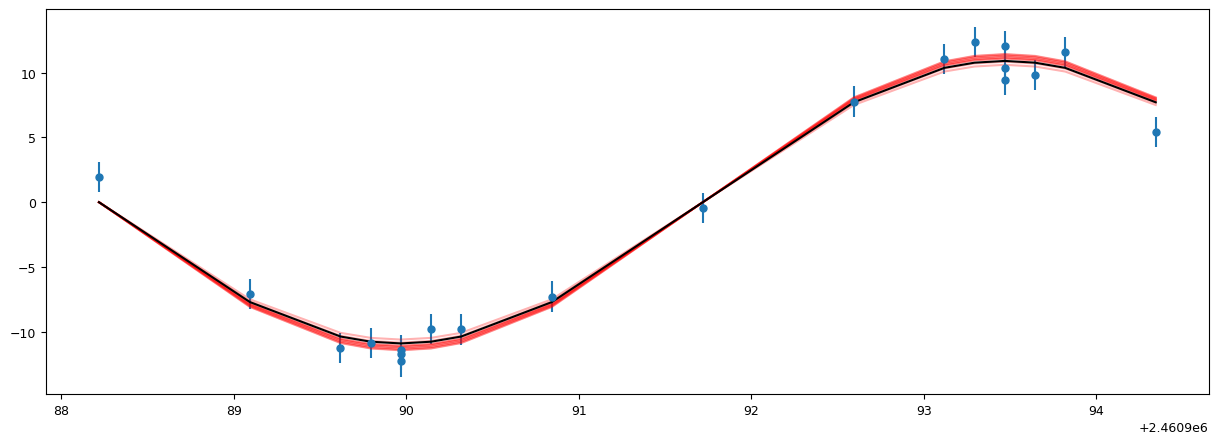

In [446]:
plt.figure(figsize=(15,5))

plt.errorbar(dates,int[0,0],int[1,0],marker="o",ls="")
for i in range(10):
    plt.plot(dates,results.rv.evaluate('HARPS',t=dataset.times_rv['HARPS'],return_samples=True)[0][i],c='r',alpha=0.3)
plt.plot(dates, RVs,c="k")

In [441]:
results.rv.evaluate('HARPS',t=dataset.times_rv['HARPS'],return_samples=True)[0].shape

(1000, 20)

In [423]:
results.rv.evaluate(instrument='HARPS',t=dates)

array([ 6.88124791e-16, -7.94641698e+00, -1.06879072e+01, -1.10995731e+01,
       -1.12379307e+01, -1.12379307e+01, -1.12379307e+01, -1.10995731e+01,
       -1.06879072e+01, -7.94641698e+00, -2.06437437e-15,  7.94641698e+00,
        1.06879072e+01,  1.10995731e+01,  1.12379307e+01,  1.12379307e+01,
        1.12379307e+01,  1.10995731e+01,  1.06879072e+01,  7.94641698e+00])

In [424]:
import juliet
priors = {}

# Name of the parameters to be fit:
params = ['P_p1','t0_p1','mu_CORALIE14', \
          'mu_CORALIE07','mu_HARPS','mu_FEROS',\
          'K_p1', 'ecc_p1', 'omega_p1', 'sigma_w_CORALIE14','sigma_w_CORALIE07',\
           'sigma_w_HARPS','sigma_w_FEROS']

# Distributions:
dists = ['normal','normal','uniform', \
         'uniform','uniform','uniform',\
         'uniform','fixed', 'fixed', 'loguniform', 'loguniform',\
         'loguniform', 'loguniform']

# Hyperparameters
hyperps = [[1.007917,0.000073], [2458325.5386,0.0011], [-100,100], \
           [-100,100], [-100,100], [-100,100], \
           [0.,100.], 0., 90., [1e-3, 100.], [1e-3, 100.], \
           [1e-3, 100.], [1e-3, 100.]]

# Populate the priors dictionary:
for param, dist, hyperp in zip(params, dists, hyperps):
    priors[param] = {}
    priors[param]['distribution'], priors[param]['hyperparameters'] = dist, hyperp

dataset = juliet.load(priors = priors, rvfilename='/Users/dhvanidoshi/Downloads/rvs_toi141.dat', out_folder = 'toi141_rvs')
results = dataset.fit(n_live_points = 300)

PyMultinest installation not detected. Forcing dynesty as the sampler.
Detected dynesty sampler output files --- extracting from toi141_rvs/_dynesty_NS_posteriors.pkl


(1365.0, 1435.0)

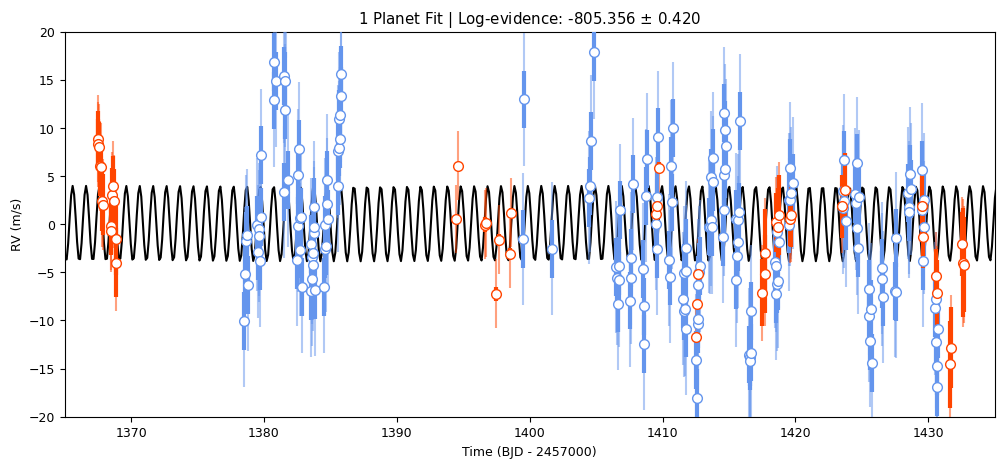

In [425]:
import numpy as np
import matplotlib.pyplot as plt

# Plot HARPS and FEROS datasets in the same panel. For this, first select any
# of the two and substract the systematic velocity to get the Keplerian signal.
# Let's do it with FEROS. First generate times on which to evaluate the model:
min_time, max_time = np.min(dataset.times_rv['FEROS'])-30,\
                     np.max(dataset.times_rv['FEROS'])+30

model_times = np.linspace(min_time,max_time,1000)

# Now evaluate the model in those times, and substract the systemic-velocity to
# get the Keplerian signal:
keplerian = results.rv.evaluate('FEROS', t = model_times) - \
            np.median(results.posteriors['posterior_samples']['mu_FEROS'])

# Now plot the (systematic-velocity corrected) RVs:
fig = plt.figure(figsize=(12,5))
instruments = ['FEROS','HARPS']
colors = ['cornflowerblue','orangered']
for i in range(len(instruments)):
    instrument = instruments[i]
    # Evaluate the median jitter for the instrument:
    jitter = np.median(results.posteriors['posterior_samples']['sigma_w_'+instrument])
    # Evaluate the median systemic-velocity:
    mu = np.median(results.posteriors['posterior_samples']['mu_'+instrument])
    # Plot original data with original errorbars:
    plt.errorbar(dataset.times_rv[instrument]-2457000,dataset.data_rv[instrument]-mu,\
                 yerr = dataset.errors_rv[instrument],fmt='o',\
                 mec=colors[i], ecolor=colors[i], elinewidth=3, mfc = 'white', \
                 ms = 7, label=instrument, zorder=10)

    # Plot original errorbars + jitter (added in quadrature):
    plt.errorbar(dataset.times_rv[instrument]-2457000,dataset.data_rv[instrument]-mu,\
                 yerr = np.sqrt(dataset.errors_rv[instrument]**2+jitter**2),fmt='o',\
                 mec=colors[i], ecolor=colors[i], mfc = 'white', label=instrument,\
                 alpha = 0.5, zorder=5)

# Plot Keplerian model:
plt.plot(model_times-2457000, keplerian,color='black',zorder=1)
plt.ylabel('RV (m/s)')
plt.xlabel('Time (BJD - 2457000)')
plt.title('1 Planet Fit | Log-evidence: {0:.3f} $\pm$ {1:.3f}'.format(results.posteriors['lnZ'],\
       results.posteriors['lnZerr']))
plt.ylim([-20,20])
plt.xlim([1365,1435])

In [450]:
sig = np.array([1/10,1/50,1/100])

As = np.array([[1,5,10,50],[1,5,10,50],[1,5,10,50]])

Ric = As + sig[:,np.newaxis]**2/As


ValueError: operands could not be broadcast together with shapes (3,4) (3,) 

In [451]:
1/As

array([[1.  , 0.2 , 0.1 , 0.02],
       [1.  , 0.2 , 0.1 , 0.02],
       [1.  , 0.2 , 0.1 , 0.02]])